<a href="https://colab.research.google.com/github/AdrianP428/DSRP_Project_MMF/blob/main/DSRP_Project_AP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_csv('loans_full_schema.csv')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earli

In [79]:
df.value_counts()

emp_title                 emp_length  state  homeownership  annual_income  verified_income  debt_to_income  annual_income_joint  verification_income_joint  debt_to_income_joint  delinq_2y  months_since_last_delinq  earliest_credit_line  inquiries_last_12m  total_credit_lines  open_credit_lines  total_credit_limit  total_credit_utilized  num_collections_last_12m  num_historical_failed_to_pay  months_since_90d_late  current_accounts_delinq  total_collection_amount_ever  current_installment_accounts  accounts_opened_24m  months_since_last_credit_inquiry  num_satisfactory_accounts  num_accounts_120d_past_due  num_accounts_30d_past_due  num_active_debit_accounts  total_debit_limit  num_total_cc_accounts  num_open_cc_accounts  num_cc_carrying_balance  num_mort_accounts  account_never_delinq_percent  tax_liens  public_record_bankrupt  loan_purpose        application_type  loan_amount  term  interest_rate  installment  grade  sub_grade  issue_month  loan_status  initial_listing_status  disbursement_method  balance   paid_total  paid_principal  paid_interest  paid_late_fees
 lead hydraulic mechanic  10.0        CO     RENT           40600.0        Source Verified  32.04           100800.0             Source Verified            32.40                 3          20.0                      2005                  7                   13                  5                  80161               64089                  0                         0                             20.0                   0                        0                             2                             2                    3.0                               5                          0.0                         0                          2                          12300              5                      3                     3                        3                  75.0                          0          0                       debt_consolidation  joint             11400        60    18.45          292.29       D      D2         Mar-2018     Current      whole                   Cash                 11043.53  853.50      356.47          497.03         0.0               1
1st grade teacher         2.0         TN     MORTGAGE       45000.0        Source Verified  28.48           80000.0              Not Verified               25.48                 0          32.0                      2003                  2                   27                  19                 177925              53762                  0                         0                             41.0                   0                        0                             2                             2                    8.0                               19                         0.0                         0                          5                          8900               20                     16                    11                       1                  92.6                          0          0                       car                 joint             2000         36    13.59          67.96        C      C2         Jan-2018     Current      fractional              Cash                 1768.26   336.78      231.74          105.04         0.0               1
account manager           7.0         NC     MORTGAGE       175000.0       Verified         18.09           210000.0             Verified                   17.62                 1          12.0                      2001                  10                  19                  10                 149097              117678                 0                         0                             53.0                   0                        0                             4                             6                    0.0                               10                         0.0                         0                          2                          3100               11                     6                     5            

In [80]:
df.head()
print(df['term'])

0       60
1       36
2       36
3       36
4       36
        ..
9995    36
9996    36
9997    36
9998    36
9999    36
Name: term, Length: 10000, dtype: int64


In [81]:
df = df.drop(columns = ['issue_month'])

In [82]:
df['has_prior_delinq'] = df['months_since_last_delinq'].notna().astype(int)
df['months_since_90d_late'] = df['months_since_last_delinq'].fillna(999)

df['has_90d_late'] = df['months_since_90d_late'].notna().astype(int)
df['months_since_90d_late'].fillna(999)

df['has_recent_inquiry'] = df['months_since_last_credit_inquiry'].notna().astype(int)
df['months_since_last_credit_inquiry'] = df['months_since_last_credit_inquiry'].fillna(999)

df['emp_length_missing'] = df['emp_length'].isna().astype(int)
df['emp_length'] = df['emp_length'].fillna(0)

In [83]:
df['dti_effective'] = df['debt_to_income_joint'].fillna(df['debt_to_income'])
df['df_missing'] = df['dti_effective'].isna().astype(int)
df['dti_effective'] = df['dti_effective'].fillna(df['dti_effective'].median())

df['is_60mo'] = (df['term'] == 60).astype(int)

In [84]:
grade = {"A1": 1, 'A2': 2, 'A3': 3, 'A4' : 4, 'A5' : 5, 'B1': 6, 'B2' : 7, 'B3' : 8, 'B4' : 9, 'B5' : 10, 'C1' : 11, 'C2' : 12, 'C3' : 13, 'C4' : 14, 'C5' : 15, 'D1' : 16, 'D2' : 17, 'D3' : 18, 'D4' : 19, 'D5' : 20, 'E1' : 21, 'E2' : 22, 'E3': 23, 'E4' : 24, 'E5' : 25, 'F1' : 26, 'F2': 27, 'F3' : 28, 'F4' : 29, 'F5': 30, 'G1': 31, 'G2' : 32, 'G3': 33, 'G4': 34, 'G5': 35}
df['grade_num'] = df['sub_grade'].map(grade)
df['grade_letter'] = df['sub_grade'].str[0]

In [85]:

df = df[df['dti_effective'] <= 100]
df = df[df['annual_income'] >= 5000]


In [107]:
df['loan_to_income'] = df['loan_amount'] / df['annual_income']
df['credit_utilized'] = np.where(df['total_credit_limit'] > 0, df['total_credit_utilized'] / df['total_credit_limit'], np.nan)
df['credit_age_years'] = 2018 - df['earliest_credit_line']

In [87]:
cap = df['annual_income'].quantile(0.99)
df['annual_income'] = df['annual_income'].clip(upper=cap)
cap = df['dti_effective'].quantile(0.99)
df['dti_effective'] = df['dti_effective'].clip(upper=cap)
cap = df['credit_utilized'].quantile(0.99)
df['credit_utilized'] = df['credit_utilized'].clip(upper=cap)
cap = df['loan_to_income'].quantile(0.99)
df['loan_to_income'] = df['loan_to_income'].clip(upper=cap)
cap = df['loan_amount'].quantile(0.99)
df['loan_amount'] = df['loan_amount'].clip(upper=cap)

In [104]:
print(df['annual_income'].sort_values())
print(df['dti_effective'].sort_values())
print(df['credit_utilized'].sort_values())
print(df['loan_to_income'].sort_values())
print(df['loan_amount'].sort_values())

7231      5000.0
6799      5000.0
2759      5208.0
2875      5235.0
8688      5500.0
          ...   
7063    300000.0
4114    300000.0
7042    300000.0
1243    300000.0
1268    300000.0
Name: annual_income, Length: 9968, dtype: float64
35       0.00
6080     0.00
5355     0.00
874      0.00
7089     0.00
        ...  
9946    37.66
205     37.66
78      37.66
9973    37.66
9924    37.66
Name: dti_effective, Length: 9968, dtype: float64
7481    0.000000
7498    0.000000
1118    0.000000
4559    0.000000
4931    0.000000
          ...   
4876    1.050814
9560    1.050814
9586    1.050814
9596    1.050814
9988    1.050814
Name: credit_utilized, Length: 9968, dtype: float64
8243    0.001282
3923    0.007500
4414    0.007692
2779    0.007910
9348    0.007937
          ...   
3490    0.964234
5107    0.964234
4867    0.964234
1913    0.964234
9491    0.964234
Name: loan_to_income, Length: 9968, dtype: float64
2857     1000
3564     1000
7960     1000
4176     1000
3460     1000
        ... 

In [103]:
df = df.dropna(subset=['credit_utilized'])
df['credit_utilized'].sort_values()

,credit_utilized
7481,0.000000
7498,0.000000
1118,0.000000
4559,0.000000
4931,0.000000
...,...
4876,1.050814
9560,1.050814
9586,1.050814
9596,1.050814


In [105]:
df['log_income'] = np.log1p(df['annual_income'])

In [89]:
print(df['dti_effective'].corr(df['grade_num']))

0.22146979154783353


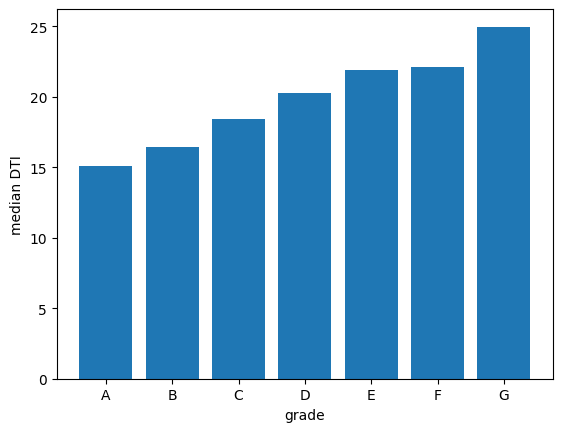

In [90]:
g = df.groupby('grade_letter')['dti_effective'].median()
x = g.index
y = g.values

plt.bar(x, y)
plt.xlabel('grade')
plt.ylabel('median DTI')
plt.show()

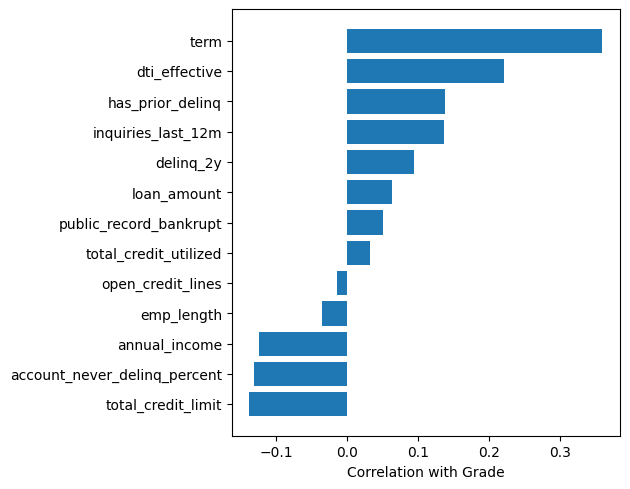

In [91]:
cols = ['dti_effective', 'annual_income', 'loan_amount', 'term', 'has_prior_delinq', 'inquiries_last_12m', 'delinq_2y', 'public_record_bankrupt', 'total_credit_utilized', 'total_credit_limit', 'open_credit_lines', 'emp_length', 'account_never_delinq_percent']
p = df[cols + ['grade_num']].corr()['grade_num'].drop('grade_num').sort_values()
plt.barh(p.index, p.values)
plt.tight_layout()
plt.xlabel('Correlation with Grade')
plt.show()

#Negative value means better grade and positive is worse grade

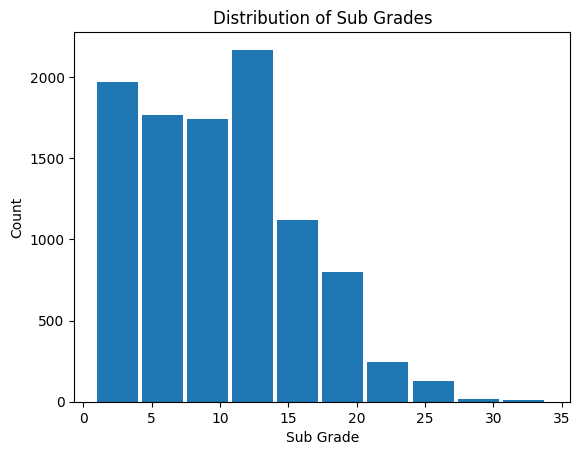

In [92]:
df['grade_num'].plot(kind = 'hist', width = 3)
plt.title("Distribution of Sub Grades")
plt.xlabel('Sub Grade')
plt.ylabel('Count')

plt.show()

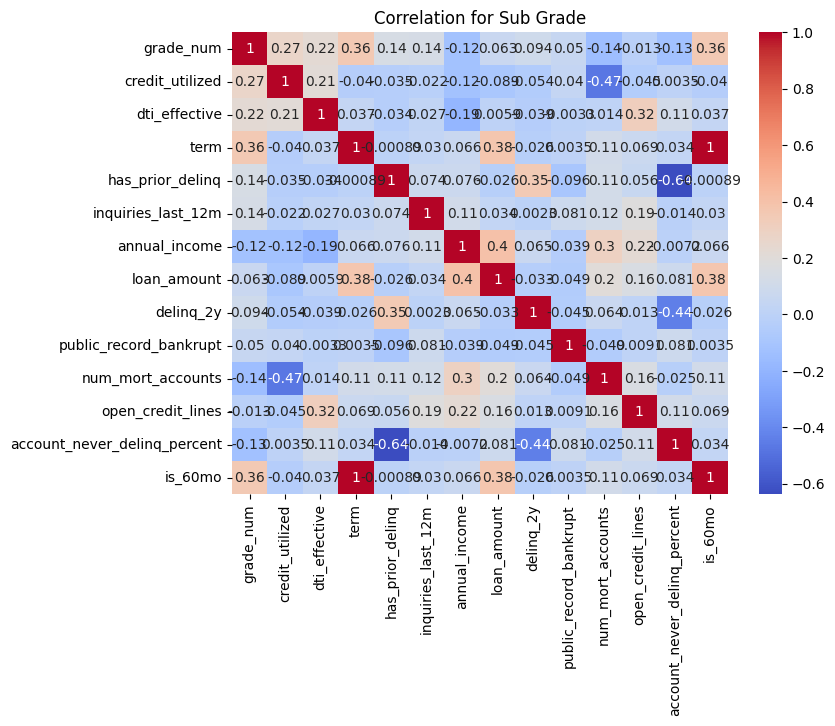

In [94]:
col = ['grade_num', 'credit_utilized', 'dti_effective', 'term',
        'has_prior_delinq', 'inquiries_last_12m', 'annual_income',
        'loan_amount', 'delinq_2y', 'public_record_bankrupt',
        'num_mort_accounts', 'open_credit_lines', 'account_never_delinq_percent','is_60mo']

correlations = df[col].corr()
plt.figure(figsize = (8,6))
sns.heatmap(correlations, annot=True, cmap = 'coolwarm')
plt.title('Correlation for Sub Grade')
plt.show()

/tmp/ipykernel_1016/1809799698.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gr = df.groupby('group_age')['has_prior_delinq'].mean() * 100


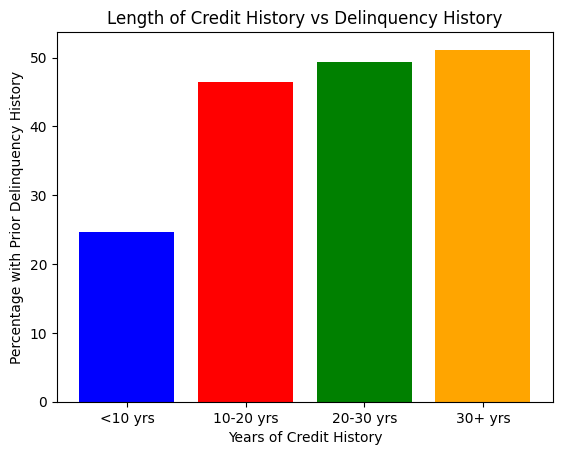

In [116]:
df['group_age'] = pd.cut(df['credit_age_years'], bins = [0,10,20,30,400])
gr = df.groupby('group_age')['has_prior_delinq'].mean() * 100
label = ['<10 yrs', '10-20 yrs', '20-30 yrs', '30+ yrs']
plt.bar(label, gr.values, color = ['blue', 'red', 'green', 'orange'])
plt.title('Length of Credit History vs Delinquency History')
plt.xlabel('Years of Credit History')
plt.ylabel('Percentage with Prior Delinquency History')
plt.show()

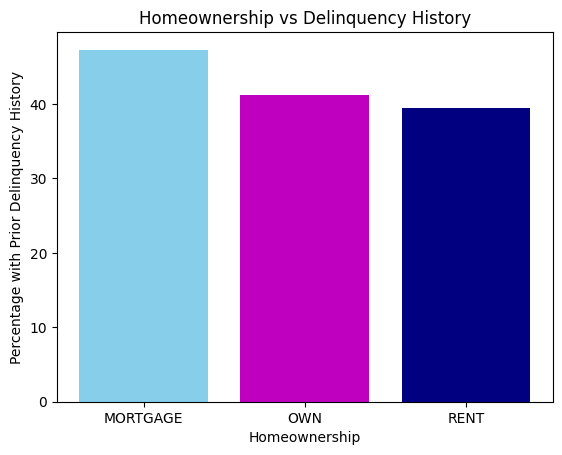

In [122]:
rates = df.groupby('homeownership')['has_prior_delinq'].mean() * 100
plt.bar(rates.index, rates.values, color = ['skyblue', 'm', 'navy'])
plt.xlabel('Homeownership')
plt.ylabel('Percentage with Prior Delinquency History')
plt.title('Homeownership vs Delinquency History')
plt.show()